In [1]:
import re
import numpy as np
import pandas as pd
import itertools
from tqdm.auto import tqdm


import matplotlib.pyplot as plt


from bert_score import score
import pymorphy3
from rapidfuzz.distance import Levenshtein
from sacrebleu.metrics import BLEU, CHRF


import warnings
import logging
from transformers import logging as hf_logging

warnings.filterwarnings("ignore")

hf_logging.set_verbosity_error()
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("bert_score").setLevel(logging.ERROR)

In [2]:
files = {
    0.0: "c2_generated_llama3_temp_0_0.csv",
    0.1: "c2_generated_llama3_temp_0_1.csv",
    0.2: "c2_generated_llama3_temp_0_2.csv",
    0.3: "c2_generated_llama3_temp_0_3.csv",
    0.4: "c2_generated_llama3_temp_0_4.csv",
    0.5: "c2_generated_llama3_temp_0_5.csv",
    0.6: "c2_generated_llama3_temp_0_6.csv",
    0.7: "c2_generated_llama3_temp_0_7.csv",
    0.8: "c2_generated_llama3_temp_0_8.csv",
    0.9: "c2_generated_llama3_temp_0_9.csv",
    1.0: "c2_generated_llama3_temp_1_0.csv",
    1.1: "c2_generated_llama3_temp_1_1.csv",
    1.2: "c2_generated_llama3_temp_1_2.csv",
    1.3: "c2_generated_llama3_temp_1_3.csv",
    1.4: "c2_generated_llama3_temp_1_4.csv",
    1.5: "c2_generated_llama3_temp_1_5.csv",
}

# Вспомогательные функции подсчета метрик

In [3]:
morph = pymorphy3.MorphAnalyzer()

def tokenize_words(text):
    text = str(text).lower()
    return re.findall(r"[а-яёa-z]+", text)


def lemmatize_text(text):
    words = tokenize_words(text)
    lemmas = [morph.parse(word)[0].normal_form for word in words]
    return lemmas

In [4]:
bleu_metric = BLEU(effective_order=True)
chrf_metric = CHRF()


def jaccard_similarity_lemmas(original, augmented):
    orig_lemmas = set(lemmatize_text(original))
    aug_lemmas = set(lemmatize_text(augmented))

    if not orig_lemmas and not aug_lemmas:
        return 1.0

    if not orig_lemmas or not aug_lemmas:
        return 0.0

    return len(orig_lemmas & aug_lemmas) / len(orig_lemmas | aug_lemmas)


def common_words_ratio(original, augmented):
    orig_lemmas = set(lemmatize_text(original))
    aug_lemmas = set(lemmatize_text(augmented))

    if not orig_lemmas:
        return 0.0

    return len(orig_lemmas & aug_lemmas) / len(orig_lemmas)


def normalized_levenshtein_distance(original, augmented):
    original = str(original)
    augmented = str(augmented)

    max_len = max(len(original), len(augmented))

    if max_len == 0:
        return 0.0

    distance = Levenshtein.distance(original, augmented)
    return distance / max_len


def normalized_levenshtein_similarity(original, augmented):
    return 1 - normalized_levenshtein_distance(original, augmented)

In [5]:
def lcs_length(x, y):
    m, n = len(x), len(y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m):
        for j in range(n):
            if x[i] == y[j]:
                dp[i + 1][j + 1] = dp[i][j] + 1
            else:
                dp[i + 1][j + 1] = max(dp[i][j + 1], dp[i + 1][j])

    return dp[m][n]


def rouge_l_f1(original, augmented):
    orig_tokens = tokenize_words(original)
    aug_tokens = tokenize_words(augmented)

    if not orig_tokens or not aug_tokens:
        return 0.0

    lcs = lcs_length(orig_tokens, aug_tokens)

    precision = lcs / len(aug_tokens)
    recall = lcs / len(orig_tokens)

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)

In [6]:
def bleu_score(original, augmented):
    score = bleu_metric.sentence_score(
        hypothesis=str(augmented),
        references=[str(original)]
    ).score

    return score / 100


def chrf_score(original, augmented):
    score = chrf_metric.sentence_score(
        hypothesis=str(augmented),
        references=[str(original)]
    ).score

    return score / 100

# Сравнение аугментированных текстов внутри одной температуры

In [7]:
def calculate_pairwise_generated_metrics(text_1, text_2):
    common_ratio_1 = common_words_ratio(text_1, text_2)
    common_ratio_2 = common_words_ratio(text_2, text_1)

    bleu_1 = bleu_score(text_1, text_2)
    bleu_2 = bleu_score(text_2, text_1)

    chrf_1 = chrf_score(text_1, text_2)
    chrf_2 = chrf_score(text_2, text_1)

    return {
        "jaccard_lemmas": jaccard_similarity_lemmas(text_1, text_2),
        "common_words_ratio": (common_ratio_1 + common_ratio_2) / 2,
        "levenshtein_distance": normalized_levenshtein_distance(text_1, text_2),
        "levenshtein_similarity": normalized_levenshtein_similarity(text_1, text_2),
        "rouge_l": rouge_l_f1(text_1, text_2),
        "bleu": (bleu_1 + bleu_2) / 2,
        "chrf": (chrf_1 + chrf_2) / 2,
    }

In [8]:
all_pairwise_rows = []

for temp, path in files.items():
    df = pd.read_csv(path)

    generated_texts = df['generated-text'].astype(str).tolist()

    pairs = list(itertools.combinations(generated_texts, 2))

    print(f"Температура {temp}: {len(generated_texts)} текстов, {len(pairs)} пар")

    for text_1, text_2 in tqdm(pairs, desc=f"Temp {temp}", total=len(pairs)):
        metrics = calculate_pairwise_generated_metrics(text_1, text_2)

        metrics["temperature"] = temp
        all_pairwise_rows.append(metrics)

pairwise_metrics_df = pd.DataFrame(all_pairwise_rows)

Температура 0.0: 120 текстов, 7140 пар


Temp 0.0:   0%|          | 0/7140 [00:00<?, ?it/s]

Температура 0.1: 120 текстов, 7140 пар


Temp 0.1:   0%|          | 0/7140 [00:00<?, ?it/s]

Температура 0.2: 120 текстов, 7140 пар


...

Temp 1.3:   0%|          | 0/7140 [00:00<?, ?it/s]

Температура 1.4: 120 текстов, 7140 пар


Temp 1.4:   0%|          | 0/7140 [00:00<?, ?it/s]

Температура 1.5: 120 текстов, 7140 пар


Temp 1.5:   0%|          | 0/7140 [00:00<?, ?it/s]

In [9]:
pairwise_metrics_df

,jaccard_lemmas,common_words_ratio,levenshtein_distance,levenshtein_similarity,rouge_l,bleu,chrf,temperature
0,0.250000,0.405294,0.532033,0.467967,0.358974,0.181115,0.472733,0.0
1,0.250000,0.405294,0.532033,0.467967,0.358974,0.181115,0.472733,0.0
2,0.250000,0.405294,0.532033,0.467967,0.358974,0.181115,0.472733,0.0
3,0.250000,0.405294,0.532033,0.467967,0.358974,0.181115,0.472733,0.0
4,0.250000,0.405294,0.532033,0.467967,0.358974,0.181115,0.472733,0.0
...,...,...,...,...,...,...,...,...
114235,0.032258,0.064777,0.774026,0.225974,0.089552,0.012683,0.231772,1.5
114236,0.026667,0.051957,0.787013,0.212987,0.048193,0.010423,0.279618,1.5
114237,0.148148,0.264957,0.734072,0.265928,0.115942,0.013257,0.306085,1.5
114238,0.119403,0.213675,0.828255,0.171745,0.070588,0.011355,0.287222,1.5


In [10]:
metric_columns = [
    "jaccard_lemmas",
    "common_words_ratio",
    "levenshtein_distance",
    "levenshtein_similarity",
    "rouge_l",
    "bleu",
    "chrf",
]

pairwise_results_df = (
    pairwise_metrics_df
    .groupby("temperature")[metric_columns]
    .agg(["mean", "std", "min", "max"])
)

In [11]:
pairwise_results_df_flat = pairwise_results_df.copy()

pairwise_results_df_flat.columns = [
    f"{metric}_{stat}"
    for metric, stat in pairwise_results_df_flat.columns
]

pairwise_results_df_flat = pairwise_results_df_flat.reset_index()

In [12]:
pairwise_results_df['jaccard_lemmas']

,mean,std,min,max
temperature,,,,
0.0,0.987500,0.096021,0.250000,1.000000
0.1,0.217231,0.139251,0.012658,1.000000
0.2,0.152093,0.084130,0.012500,1.000000
0.3,0.137877,0.072996,0.000000,0.794872
0.4,0.125226,0.061063,0.000000,0.547170
0.5,0.116166,0.062308,0.000000,0.511111
0.6,0.097525,0.051903,0.000000,0.437500
0.7,0.086561,0.040382,0.000000,0.311475
0.8,0.092203,0.045811,0.000000,0.322034


In [13]:
pairwise_results_df['common_words_ratio']

,mean,std,min,max
temperature,,,,
0.0,0.990088,0.076139,0.405294,1.000000
0.1,0.341877,0.157411,0.025000,1.000000
0.2,0.257458,0.114383,0.024725,1.000000
0.3,0.238443,0.106039,0.000000,0.886438
0.4,0.221117,0.093348,0.000000,0.707317
0.5,0.205736,0.095356,0.000000,0.691424
0.6,0.177447,0.084209,0.000000,0.615025
0.7,0.159780,0.067163,0.000000,0.507371
0.8,0.169206,0.075452,0.000000,0.488464


In [14]:
pairwise_results_df['levenshtein_distance']

,mean,std,min,max
temperature,,,,
0.0,0.008867,0.068115,0.000000,0.532033
0.1,0.694014,0.147244,0.000000,0.859008
0.2,0.753802,0.076946,0.000000,0.862259
0.3,0.754869,0.063515,0.139601,0.868421
0.4,0.757742,0.046328,0.415049,0.856397
0.5,0.763858,0.041795,0.427056,0.853960
0.6,0.773137,0.037918,0.401554,0.967890
0.7,0.773457,0.030405,0.500000,0.908136
0.8,0.774089,0.033611,0.601796,0.944079


In [15]:
pairwise_results_df['levenshtein_similarity']

,mean,std,min,max
temperature,,,,
0.0,0.991133,0.068115,0.467967,1.000000
0.1,0.305986,0.147244,0.140992,1.000000
0.2,0.246198,0.076946,0.137741,1.000000
0.3,0.245131,0.063515,0.131579,0.860399
0.4,0.242258,0.046328,0.143603,0.584951
0.5,0.236142,0.041795,0.146040,0.572944
0.6,0.226863,0.037918,0.032110,0.598446
0.7,0.226543,0.030405,0.091864,0.500000
0.8,0.225911,0.033611,0.055921,0.398204


In [16]:
pairwise_results_df['rouge_l']

,mean,std,min,max
temperature,,,,
0.0,0.989316,0.082069,0.358974,1.000000
0.1,0.213886,0.167555,0.000000,1.000000
0.2,0.138029,0.090569,0.021053,1.000000
0.3,0.125143,0.074098,0.000000,0.831169
0.4,0.114308,0.056161,0.000000,0.562500
0.5,0.102887,0.052154,0.000000,0.540541
0.6,0.090922,0.045325,0.000000,0.543210
0.7,0.083487,0.037005,0.000000,0.492308
0.8,0.085461,0.038108,0.000000,0.327273


In [17]:
pairwise_results_df['bleu']

,mean,std,min,max
temperature,,,,
0.0,0.986352,0.104840,0.181115,1.000000
0.1,0.101122,0.160943,0.007823,1.000000
0.2,0.045450,0.074936,0.005833,1.000000
0.3,0.038042,0.050681,0.006114,0.737219
0.4,0.029275,0.029920,0.005254,0.379364
0.5,0.026492,0.024905,0.006455,0.343686
0.6,0.022780,0.019319,0.004155,0.317159
0.7,0.020375,0.013188,0.006048,0.227858
0.8,0.020122,0.014753,0.002612,0.211227


In [18]:
pairwise_results_df['chrf']

,mean,std,min,max
temperature,,,,
0.0,0.991212,0.067505,0.472733,1.000000
0.1,0.401776,0.129670,0.209522,1.000000
0.2,0.344562,0.080030,0.181333,1.000000
0.3,0.335065,0.068160,0.168540,0.854928
0.4,0.320489,0.059588,0.177044,0.653733
0.5,0.311429,0.058701,0.174158,0.617911
0.6,0.293651,0.060736,0.004454,0.616770
0.7,0.288932,0.039837,0.129834,0.569907
0.8,0.289436,0.046691,0.080705,0.510396


In [19]:
def plot_pairwise_metric(results_df, metric_name, title, ylabel):
    plt.figure(figsize=(8, 5))

    plt.plot(
        results_df["temperature"],
        results_df[f"{metric_name}_mean"],
        marker="o"
    )

    plt.xticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
    plt.xlabel("Температура генерации")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid()

    plt.show()

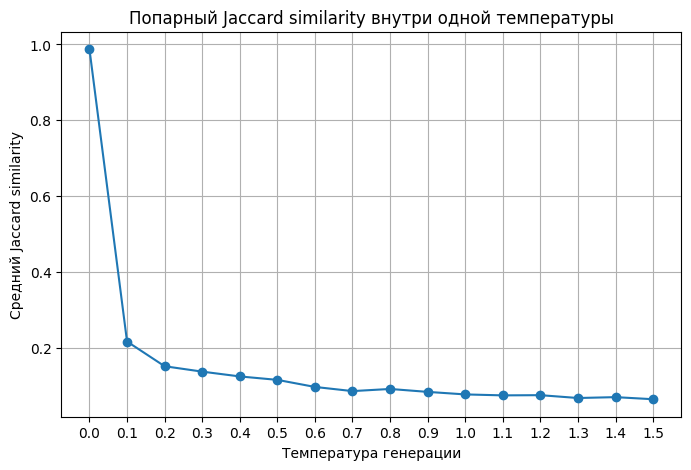

In [20]:
plot_pairwise_metric(
    pairwise_results_df_flat,
    "jaccard_lemmas",
    "Попарный Jaccard similarity внутри одной температуры",
    "Средний Jaccard similarity"
)

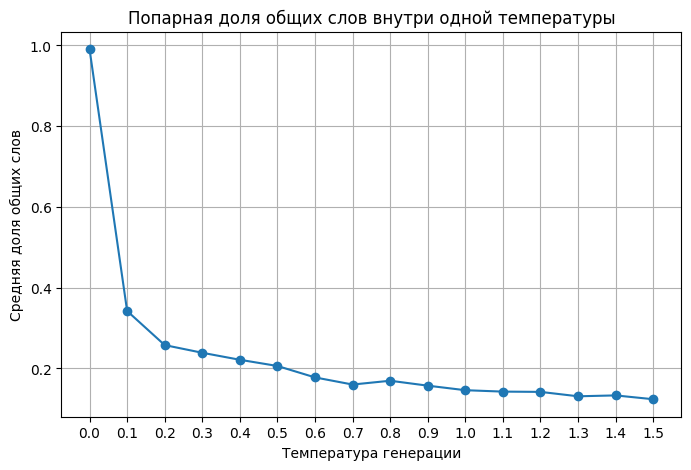

In [21]:
plot_pairwise_metric(
    pairwise_results_df_flat,
    "common_words_ratio",
    "Попарная доля общих слов внутри одной температуры",
    "Средняя доля общих слов"
)

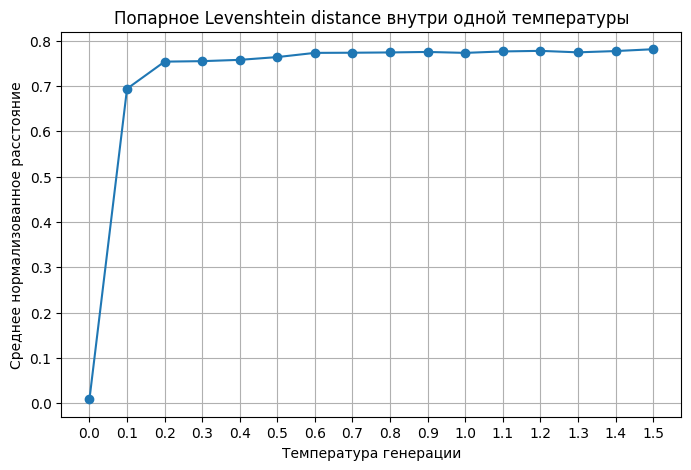

In [22]:
plot_pairwise_metric(
    pairwise_results_df_flat,
    "levenshtein_distance",
    "Попарное Levenshtein distance внутри одной температуры",
    "Среднее нормализованное расстояние"
)

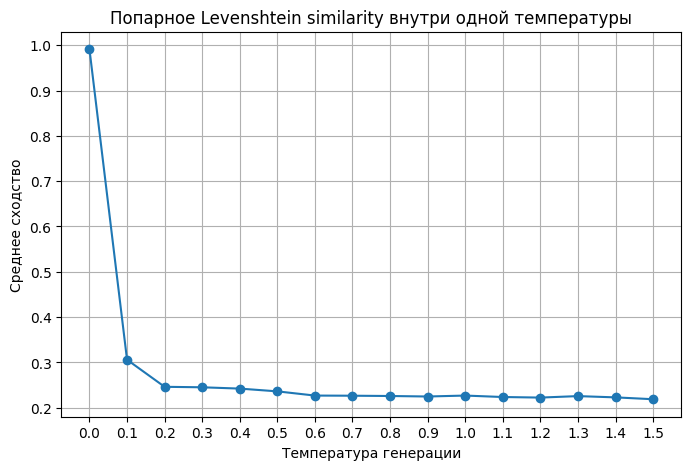

In [23]:
plot_pairwise_metric(
    pairwise_results_df_flat,
    "levenshtein_similarity",
    "Попарное Levenshtein similarity внутри одной температуры",
    "Среднее сходство"
)

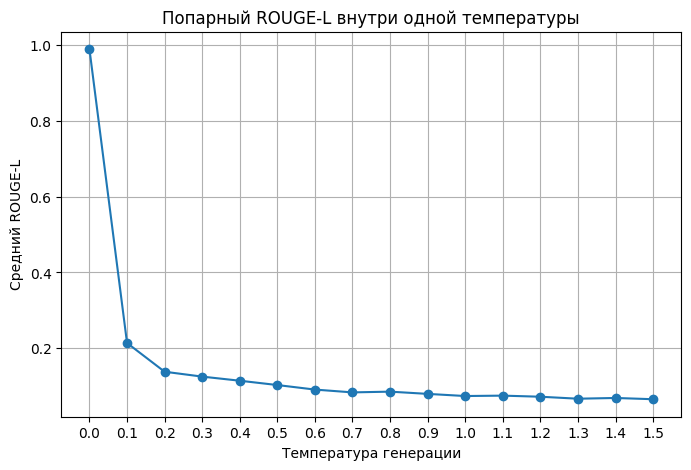

In [24]:
plot_pairwise_metric(
    pairwise_results_df_flat,
    "rouge_l",
    "Попарный ROUGE-L внутри одной температуры",
    "Средний ROUGE-L"
)

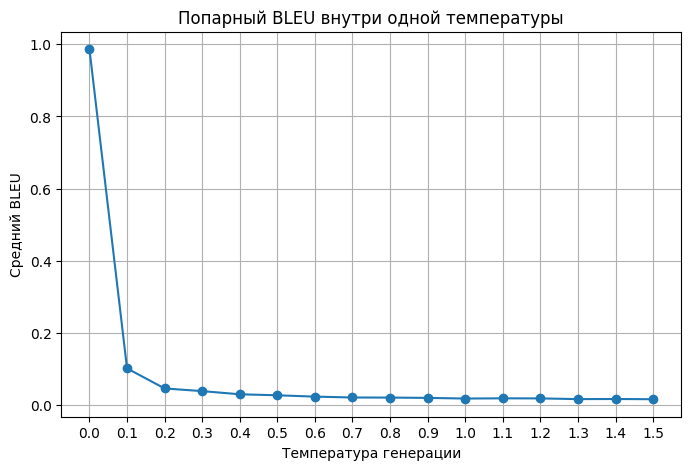

In [25]:
plot_pairwise_metric(
    pairwise_results_df_flat,
    "bleu",
    "Попарный BLEU внутри одной температуры",
    "Средний BLEU"
)

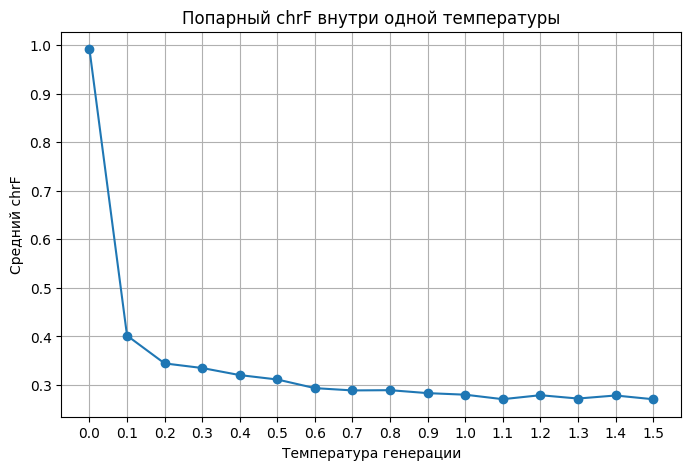

In [26]:
plot_pairwise_metric(
    pairwise_results_df_flat,
    "chrf",
    "Попарный chrF внутри одной температуры",
    "Средний chrF"
)